# Multi-Anchor Spatial ResNet Object Detector (Stage 7)

Trains `ObjectDetectorResNet` with a multi-anchor grid spatial head ($S \times S \times K$) to predict bounding boxes and character classes.
Each spatial cell predicts $K=3$ anchor slots `[x, y, w, h, conf]`, using **Focal Loss** for objectness confidence and Aligned IoU loss for localization.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` ($K=3$) → `DetectionLoss` (Focal Loss) → `fit()`


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from utils.dataset import get_detection_loaders, S, K
from generator.dataset import EMNIST_CLASS_NAMES
from utils.trainer import fit, evaluate_detection, evaluate_detection_sweep
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from utils.losses import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
GRID_SIZE   = S        # 14x14 grid
CONF_THRESH = 0.5     # sigmoid threshold at inference
MODEL_SIZE  = 'n'
CLASS_NAMES = EMNIST_CLASS_NAMES['bymerge']
NUM_ANCHORS = K
USE_FOCAL_LOSS = True
FOCAL_ALPHA    = 0.25
FOCAL_GAMMA    = 2.0
USE_POS_WEIGHT = False

print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')
print(f'Grid Size: {GRID_SIZE}x{GRID_SIZE}')


Device   : cuda
PyTorch  : 2.11.0+cu130
Grid Size: 14x14


## 1 · Data Loaders


In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, targets, labels = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT grid targets   : {targets.shape}')  # (B, S, S, 5)
print(f'GT grid labels    : {labels.shape}')   # (B, S, S)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Image batch shape : torch.Size([198, 1, 224, 224])
GT grid targets   : torch.Size([198, 14, 14, 3, 5])
GT grid labels    : torch.Size([198, 14, 14, 3])
Train batches: 1213 | Val batches: 76


## 2 · Model Architecture


In [3]:
model = get_detector(size=MODEL_SIZE).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, S, S, 5 + num_classes)


Parameters: 406,204
Output shape: torch.Size([198, 14, 14, 3, 52])


## 3 · Loss Function, Optimiser & Scheduler


In [4]:
criterion = DetectionLoss(
    lambda_conf    = 1.0,
    lambda_class   = 1.0,
    lambda_iou     = 1.0,
    use_focal_loss = USE_FOCAL_LOSS,
    focal_alpha    = FOCAL_ALPHA,
    focal_gamma    = FOCAL_GAMMA,
    use_pos_weight = USE_POS_WEIGHT,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = f"{NUM_ANCHORS}_grid_detector_{MODEL_SIZE}"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_f1
)

scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

print(f'Criterion : {type(criterion).__name__}')
print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')


Criterion : DetectionLoss
Optimizer : AdamW
Scheduler : OneCycleLR


## 4 · Training


In [5]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    # resume      = True,
)


Training with bf16 autocast | Epochs: 60
[RunLogger] ▶  Run '3_grid_detector_n_20260815_102406' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\3_grid_detector_n_20260815_102406.json'
Batch  1 | data=700.9ms pad=1.1ms forward=159.8ms loss=244.9ms backward=325.1ms step=172.8ms
Batch  2 | data=0.2ms pad=0.8ms forward=8.9ms loss=3.3ms backward=24.9ms step=1.9ms
Batch  3 | data=0.2ms pad=0.8ms forward=8.8ms loss=2.1ms backward=22.8ms step=1.3ms
Batch  4 | data=0.1ms pad=0.8ms forward=8.8ms loss=2.9ms backward=23.7ms step=1.4ms
Batch  5 | data=0.2ms pad=0.9ms forward=8.8ms loss=2.9ms backward=23.5ms step=1.9ms
Train: 96.1s | Val: 44.2s
  --> Det  | PR: 0.024 | Rec: 0.009 | F1: 0.013 | TP: 1028 FP: 41754 FN: 118877
  --> Cls  | Acc: 0.079
  --> E2E  | F1: 0.001 | PR: 0.002 | Rec: 0.001
[RunLogger] Epoch   1 | train_loss=41.6835  val_loss=27.0713  val_f1=0.0010%  lr=4.73e-05  ⏱ 96.1s  ★ NEW BEST
Batch  1 | data=714.9ms pad=1.2ms forward=12.6ms loss=7.5ms backward=44.4ms step

## 5 · Training Dashboard & Curves


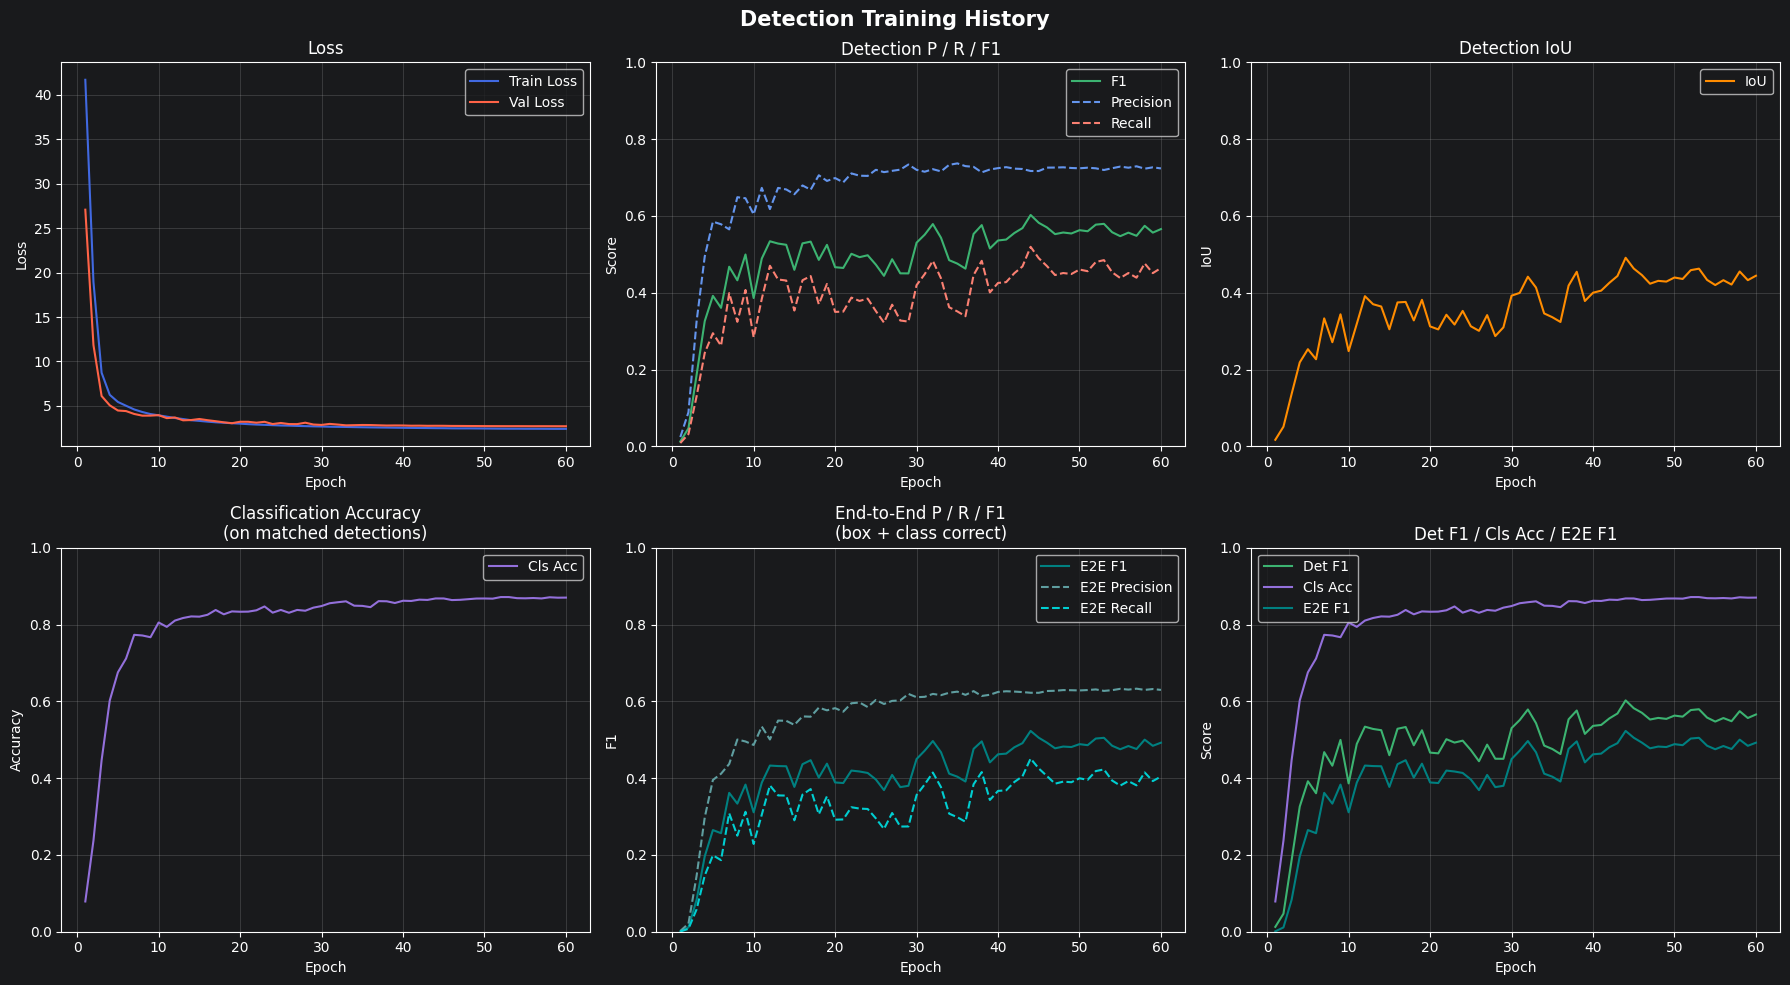

In [6]:
# Full detection training dashboard (Loss, Det P/R/F1, IoU, Cls Acc, E2E P/R/F1)
Visualizer.visualize_detection_history(history)


## 6 · Final Evaluation on Test Set


In [7]:
# Load best checkpoint weights if checkpoint callback was used
if 'checkpoint' in locals() and checkpoint is not None:
    checkpoint.restore_best_weights()

metrics = evaluate_detection(model, test_loader, criterion, DEVICE, conf_threshold=CONF_THRESH)

det = metrics['detection']
cls = metrics['classification']
e2e = metrics['end_to_end']

print('=== Detection (localisation) ===')
print(f"  Loss     : {metrics['loss']:.4f}")
print(f"  IoU      : {det['iou']:.4f}")
print(f"  Precision: {det['precision']:.4f}")
print(f"  Recall   : {det['recall']:.4f}")
print(f"  F1       : {det['f1']:.4f}")
print(f"  TP/FP/FN : {det['tp']} / {det['fp']} / {det['fn']}")

print('\n=== Classification (on matched detections) ===')
print(f"  Accuracy : {cls['accuracy']:.4f}")
print('  Per-class:')
for k, v in cls['per_class'].items():
    name = v.get('name', f'class_{k}')
    print(f"    [{k}] {name}: acc={v['accuracy']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}  e2e_f1={v['e2e_f1']:.4f}")

print('\n=== End-to-End (box + class correct) ===')
print(f"  Precision: {e2e['precision']:.4f}")
print(f"  Recall   : {e2e['recall']:.4f}")
print(f"  F1       : {e2e['f1']:.4f}")
print(f"  TP/FP/FN : {e2e['tp']} / {e2e['fp']} / {e2e['fn']}")


=== Detection (localisation) ===
  Loss     : 2.7533
  IoU      : 0.4908
  Precision: 0.7226
  Recall   : 0.5209
  F1       : 0.6054
  TP/FP/FN : 187811 / 72102 / 172756

=== Classification (on matched detections) ===
  Accuracy : 0.8616
  Per-class:
    [0] class_0: acc=0.7220  e2e_p=0.4729  e2e_r=0.4335  e2e_f1=0.4523
    [1] class_1: acc=0.5260  e2e_p=0.4147  e2e_r=0.3708  e2e_f1=0.3915
    [2] class_2: acc=0.8817  e2e_p=0.7047  e2e_r=0.4529  e2e_f1=0.5514
    [3] class_3: acc=0.9641  e2e_p=0.7482  e2e_r=0.4965  e2e_f1=0.5969
    [4] class_4: acc=0.9086  e2e_p=0.7171  e2e_r=0.5110  e2e_f1=0.5968
    [5] class_5: acc=0.8893  e2e_p=0.6872  e2e_r=0.4691  e2e_f1=0.5576
    [6] class_6: acc=0.8943  e2e_p=0.7022  e2e_r=0.4785  e2e_f1=0.5691
    [7] class_7: acc=0.9653  e2e_p=0.6997  e2e_r=0.5665  e2e_f1=0.6261
    [8] class_8: acc=0.9197  e2e_p=0.7023  e2e_r=0.4915  e2e_f1=0.5783
    [9] class_9: acc=0.7425  e2e_p=0.5532  e2e_r=0.4714  e2e_f1=0.5091
    [10] class_10: acc=0.9557  e2e_p=0.

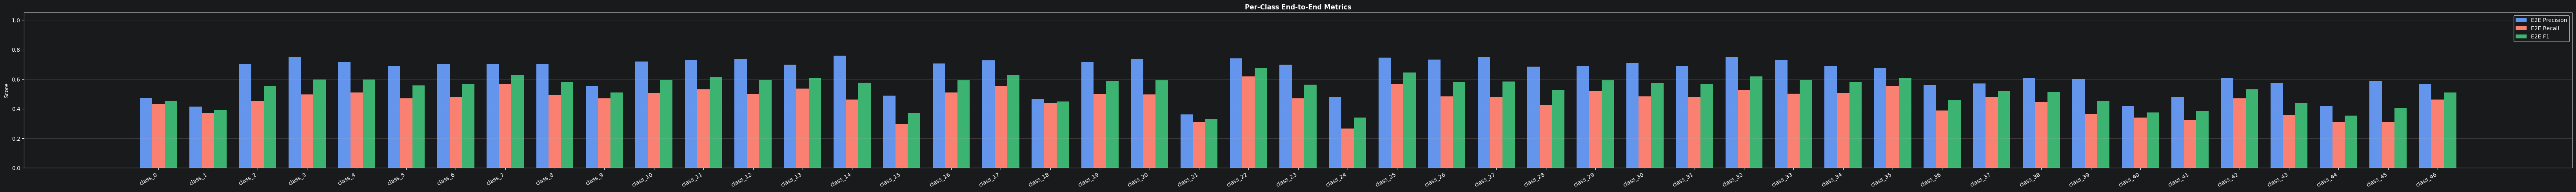

In [8]:
Visualizer.visualize_per_class_e2e(metrics)

## 7 · Prediction Visualisation

- **Lime** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH` (plus NMS)


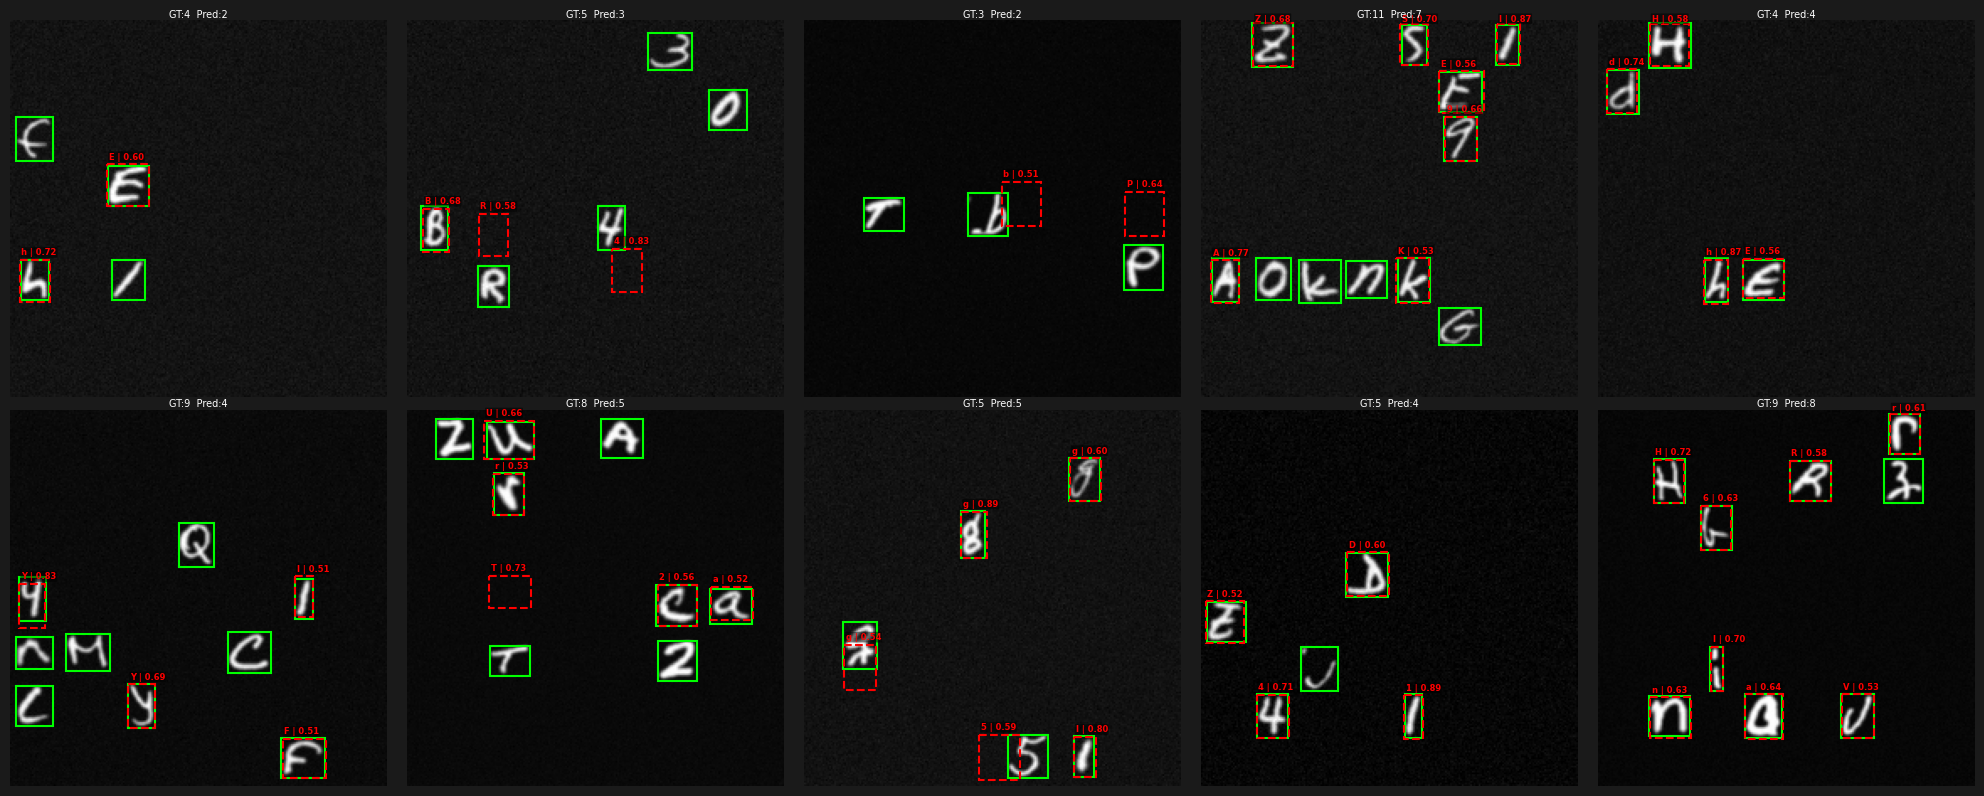

In [9]:
test_batch = next(iter(test_loader))
imgs_t, targets_t, labels_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()

Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    gt_grid=targets_t,
    conf_thresh=CONF_THRESH,
    class_names=CLASS_NAMES,
)


## 8 · Confidence Threshold Sweep

Sweeps confidence thresholds on the held-out **test set** to evaluate the full Precision / Recall / F1 trade-off.


In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    conf_thresholds=np.arange(0.1, 0.95, 0.05),
    iou_threshold=0.5,
    print_table=True,
)

if 'logger' in locals() and logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1   ClsAcc       TP       FP       FN
------------------------------------------------------------------
  0.10  0.3177  0.7541  0.4470   0.8670   271899   584063    88668
  0.15  0.3731  0.7490  0.4981   0.8675   270059   453765    90508
  0.20  0.4228  0.7443  0.5393   0.8680   268373   366405    92194
  0.25  0.4717  0.7393  0.5759   0.8684   266564   298535    94003
  0.30  0.5241  0.7316  0.6107   0.8687   263773   239526    96794
  0.35  0.5837  0.7151  0.6428   0.8686   257846   183881   102721
  0.40  0.6437  0.6792  0.6610   0.8680   244899   135530   115668
  0.45  0.6917  0.6142  0.6507   0.8656   221469    98722   139098
  0.50  0.7226  0.5209  0.6054   0.8616   187811    72102   172756
  0.55  0.7360  0.4255  0.5392   0.8559   153413    55018   207154
  0.60  0.7435  0.3304  0.4575   0.8476   119141    41100   241426
  0.65  0.7478  0.2468  0.3711   0.8371    88978    30005   271589
  0.70  0.7508  0.1799  0.2902   0.8250    64850    21525   2

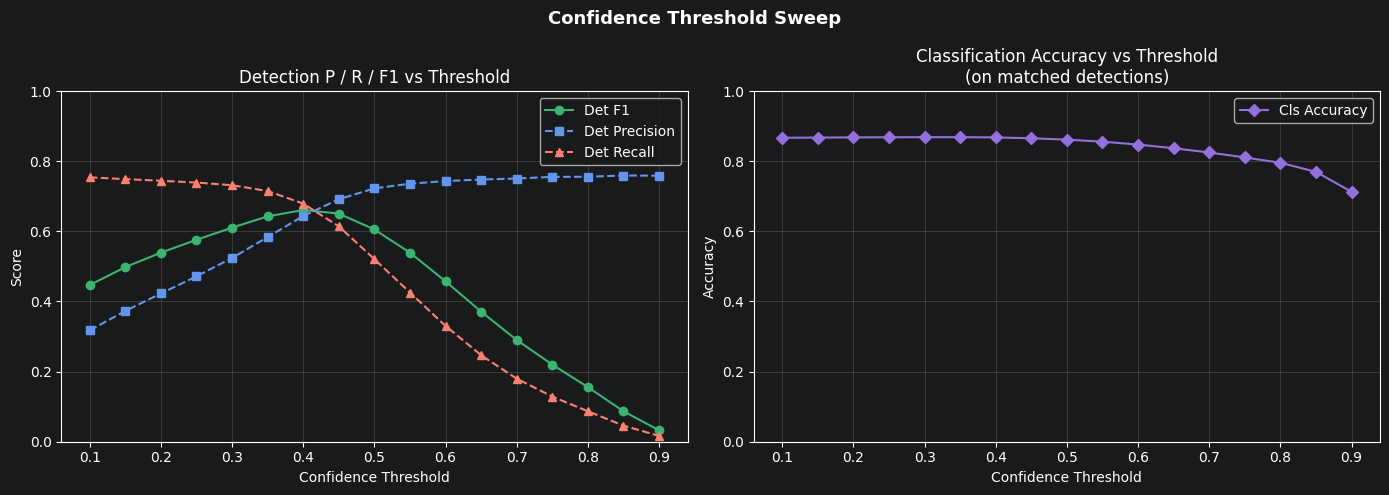


Best conf threshold : 0.40
  Det  F1  = 0.6610
  Cls  Acc = 0.8680
Per-class E2E F1:
  [0] class_0: e2e_f1=0.4564  e2e_p=0.4056  e2e_r=0.5219
  [1] class_1: e2e_f1=0.3912  e2e_p=0.3868  e2e_r=0.3957
  [2] class_2: e2e_f1=0.6314  e2e_p=0.6266  e2e_r=0.6363
  [3] class_3: e2e_f1=0.6690  e2e_p=0.6536  e2e_r=0.6852
  [4] class_4: e2e_f1=0.6456  e2e_p=0.6254  e2e_r=0.6672
  [5] class_5: e2e_f1=0.6180  e2e_p=0.5940  e2e_r=0.6441
  [6] class_6: e2e_f1=0.6385  e2e_p=0.6375  e2e_r=0.6395
  [7] class_7: e2e_f1=0.6420  e2e_p=0.5913  e2e_r=0.7022
  [8] class_8: e2e_f1=0.6448  e2e_p=0.6311  e2e_r=0.6590
  [9] class_9: e2e_f1=0.5162  e2e_p=0.4935  e2e_r=0.5411
  [10] class_10: e2e_f1=0.6602  e2e_p=0.6273  e2e_r=0.6969
  [11] class_11: e2e_f1=0.6767  e2e_p=0.6531  e2e_r=0.7020
  [12] class_12: e2e_f1=0.6622  e2e_p=0.6379  e2e_r=0.6884
  [13] class_13: e2e_f1=0.6456  e2e_p=0.6115  e2e_r=0.6837
  [14] class_14: e2e_f1=0.6689  e2e_p=0.6675  e2e_r=0.6703
  [15] class_15: e2e_f1=0.4314  e2e_p=0.4399  e2e

In [11]:
# Plot Det P/R/F1 and Cls Accuracy across thresholds
Visualizer.visualize_sweep_results(sweep_results)

# Per-class E2E F1 at best Det-F1 threshold
best_r = max(sweep_results, key=lambda r: r['f1'])
print(f"\nBest conf threshold : {best_r['conf']:.2f}")
print(f"  Det  F1  = {best_r['f1']:.4f}")
print(f"  Cls  Acc = {best_r['cls_accuracy']:.4f}")
print('Per-class E2E F1:')
for k, v in best_r['per_class_e2e'].items():
    name = v.get('name', f'class_{k}')
    print(f"  [{k}] {name}: e2e_f1={v['e2e_f1']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}")
